# dirFR sample plots — primacy vs recency initiation

This notebook reuses `analyses.spc_sess` and `analyses.pfr_sess` from `analyses.py`
— the per-session computation functions, but bypasses the groupby wrappers that
were written for the old MTurk design's stimulus conditions.

## 0. Load and Clean

In [143]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import analyses.analyses as analyses
import analyses.statistics as stat_tests
import analyses.mwr as mwr 
import warnings; warnings.filterwarnings('ignore')
from data.spellcheck import spellcheck_recalls_dl
from data.prolific_quality import filter_sessions_by_quality
from data.recall_inspection import inspect_list_recall

In [144]:
# Loads the most recent pulled CSV file from data/data_storage 
data_dir = Path('data/data_storage') # create path to folder 
try:
    data_path = max(data_dir.glob('dirfr_trials*.csv'), key=lambda p: p.stat().st_mtime) # get most recent trial csv
except ValueError:
    raise FileNotFoundError(f'No dirfr_trials*.csv files found in {data_dir}')
raw = pd.read_csv(data_path)
print(f'Loaded {data_path}')

Loaded data\data_storage\dirfr_trials_20260603_220902.csv


In [145]:
# Manual Exclusion
exclude_pid = ['5ece82a1ba09f524e15d973b', '602fd11faa844cd2d0fd5818', '69f0ef2a58d846e3bbe5a68f']
print(f'Before exclusion: {len(raw)} rows')
raw = raw[~raw['prolific_pid'].isin(exclude_pid)].copy()
print(f'After exclusion: {len(raw)} rows')
print(f'Excluded data (Prolific IDs: {exclude_pid})')

Before exclusion: 182605 rows
After exclusion: 177213 rows
Excluded data (Prolific IDs: ['5ece82a1ba09f524e15d973b', '602fd11faa844cd2d0fd5818', '69f0ef2a58d846e3bbe5a68f'])


In [146]:
# Keep only word-presentation and recall rows - analyses.spc_sess / pfr_sess use these
df = raw[raw['type'].isin(['WORD', 'REC_WORD'])].copy()

# Ensure numeric dtypes (raw CSV mixes schemas across rows)
for col in ['serial_position', 'list', 'session', 'l_length', 'rt']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Check
type(df['serial_position'].iloc[0]), type(df['list'].iloc[0]), type(df['session'].iloc[0]), type(df['l_length'].iloc[0]), type(df['rt'].iloc[0])

(numpy.float64, numpy.float64, numpy.int64, numpy.float64, numpy.float64)

In [147]:
# Build lookup: presented WORD -> serial position
word_rows = df[df['type'] == 'WORD'].copy()
word_rows['word_key'] = word_rows['word'].str.lower().str.strip()
word_maps = word_rows.set_index(
    ['prolific_pid', 'session', 'list', 'word_key']
)['serial_position'].to_dict()

# recompute serial positions for REC_WORD
def recover_sp(row):
    if row['type'] != 'REC_WORD':
        return row['serial_position']
    if pd.isna(row['rec_word']) or str(row['rec_word']).strip() in ['', 'null']:
        return 99
    key = (row['prolific_pid'], row['session'], row['list'], str(row['rec_word']).lower().strip())
    return word_maps.get(key, 88) # return serial position if found else 88 

df['serial_position'] = df.apply(recover_sp, axis=1)
df = spellcheck_recalls_dl(df) # add spellcheck following original study, Levenshtein dist <= 1 

Damerau-Levenshtein spellcheck corrected 2170 recall(s).


In [148]:
df_before_quality = df.copy()
df_after_quality = filter_sessions_by_quality(df_before_quality, raw)

before_sessions = df_before_quality[['prolific_pid', 'session']].drop_duplicates()
after_sessions = df_after_quality[['prolific_pid', 'session']].drop_duplicates()

excluded_sessions = (
    before_sessions
    .merge(after_sessions, on=['prolific_pid', 'session'], how='left', indicator=True)
    .query("_merge == 'left_only'")
    .drop(columns='_merge')
    .sort_values(['prolific_pid', 'session'])
)

excluded = len(excluded_sessions)

print(f"Excluded sessions by quality criteria: {excluded}")
display(excluded_sessions)

df = df_after_quality


Participant 68d850c1c461a91aa0382734 in session 1 had 6 trials with zero correct recalls.
Participant 69dc70961c94f47c2fdced04 in session 0 took notes.
Participant 6a02a3d567b030856033eb52 in session 0 took notes.
Excluded sessions by quality criteria: 3


,prolific_pid,session
295,68d850c1c461a91aa0382734,1
174,69dc70961c94f47c2fdced04,0
313,6a02a3d567b030856033eb52,0


## 1. Inspection

In [149]:
study_ids = df['study_id'].unique()
print(f"Unique study IDs in the dataset: {study_ids}")

Unique study IDs in the dataset: <StringArray>
['69d46e02eb60e403061e3838', '69d471615d93c0c79dee79ab',
 '69d471fc7a8b81688aee48f7', '69d472c7196fbc6a00542c17',
 '69d4731bcc7b5579cfac3f7f']
Length: 5, dtype: str


In [150]:
# Metadata Inspection
session_info = df[['prolific_pid', 'session', 'initiation_condition']].drop_duplicates(['prolific_pid', 'session'])
twoplus_sessions = session_info.groupby('prolific_pid')['session'].nunique().loc[lambda s: s > 2]
print(f'{len(df)} rows across {session_info["prolific_pid"].nunique()} participants, {len(session_info)} sessions')
print(f"Condition breakdown by session: {session_info['initiation_condition'].value_counts().to_dict()}")
print(f'Participants with 2+ included session: {len(twoplus_sessions)}')

print("Total Sessions Completed:", session_info['session'].nunique())
counts = session_info['session'].value_counts().sort_index()
counts.index = [f"Session {i}" for i in counts.index]
print(counts)

142554 rows across 171 participants, 457 sessions
Condition breakdown by session: {'primacy': 252, 'recency': 205}
Participants with 2+ included session: 80
Total Sessions Completed: 5
Session 0    170
Session 1    127
Session 2     81
Session 3     49
Session 4     30
Name: count, dtype: int64


In [106]:
# Per-Subject Inspection
pid = '6a033ca78f693eb88b355743' # (replace with actual Prolific ID of interest)

# 1) Number of sessions completed
n_sessions = session_info[session_info['prolific_pid'] == pid]['session'].nunique()

# 2) Condition per session
print(f"Condition per Session:")
for i in range(n_sessions):
    condition = session_info[(session_info['prolific_pid'] == pid) & (session_info['session'] == i)]['initiation_condition'].iloc[0]
    print(f"Session {i}: {condition}")

# 3) Mean words recalled per list per session
print(f"Mean Words Recalled per Session:")
for i in range(n_sessions):
    data = df_before_quality[(df_before_quality['prolific_pid'] == pid) & (df_before_quality['session'] == i)]
    mean_words = mwr.mwr_sess(data)
    print(f"Session {i}: {mean_words}")

Condition per Session:
Mean Words Recalled per Session:


In [196]:
# Per-List Inspection
pid = '69af89f9a007e159445fa6df' # (replace with actual Prolific ID of interest)
session = 2
list_num = 11

selected = df.query("prolific_pid == @pid and session == @session and list == @list_num")
condition = selected['initiation_condition'].dropna().iloc[0]
ll = int(selected['l_length'].dropna().iloc[0])
recalls = selected[selected['type'] == 'REC_WORD']['serial_position']
correct_unique = recalls[(recalls >= 1) & (recalls <= ll)].astype(int).nunique()

print(f'Participant {pid}, Session {session}, List {list_num}')
print(f'Initiation direction: {condition}')
print(f'Words recalled: {correct_unique}')
inspect_list_recall(df, pid, session, list_num)

Participant 69af89f9a007e159445fa6df, Session 2, List 11
Initiation direction: recency
Words recalled: 5


,serial_position,word_shown,recalled_word,recalled_serial_position,intrusion_type
row,,,,,
1,1,lover,frame,20,correct
2,2,pilot,oyster,19,correct
3,3,trout,daughter,13,correct
4,4,scarecrow,concert,5,correct
5,5,concert,rifle,"PLI: list 10, SP 19",PLI
6,6,student,oyster,19,correct
7,7,preacher,lover,1,correct
8,8,scotch,(empty),no response,no response
9,9,yarn,NaN,NaN,NaN


## T-test for non-random attrition

In [108]:
import analyses.mwr as mwr

In [109]:
print(df.columns)

Index(['success', 'trial_type', 'trial_index', 'time_elapsed',
       'internal_node_id', 'num_lists', 'session', 'replays', 'prolific_pid',
       'study_id', 'session_id', 'initiation_condition', 'rt', 'stimulus',
       'response', 'color', 'type', 'age', 'view_history', 'word',
       'serial_position', 'list', 'recall_position', 'is_first_recall',
       'rec_word', 'notes', 'row_id', 'l_length', 'pres_rate'],
      dtype='str')


In [110]:
filtered_p0ids = df[df['session'] == 0]['prolific_pid'].unique()
filtered_p1ids = df[df['session'] == 1]['prolific_pid'].unique()
p0_not_p1 = set(filtered_p0ids) - set(filtered_p1ids)
p0_not_p1_df = df[(df['prolific_pid'].isin(p0_not_p1)) & (df['session'] == 0)]
p0_with_p1_df = df[(df['prolific_pid'].isin(filtered_p1ids)) & (df['session'] == 0)]

In [111]:
mwr_p0notp1 = mwr.mwr(p0_not_p1_df)
mwr_p1plus = mwr.mwr(p0_with_p1_df)

In [112]:
from scipy import stats

mwr_0 = mwr_p0notp1['mwr'].dropna()
mwr_1 = mwr_p1plus['mwr'].dropna()

print(f"n (p0 not p1) = {len(mwr_0)}")
print(f"mean (p0 not p1) = {mwr_0.mean():.3f}")
print(f"n (p1 plus) = {len(mwr_1)}")
print(f"mean (p1 plus) = {mwr_1.mean():.3f}")

t_stat, p_value = stats.ttest_ind(mwr_0, mwr_1, equal_var=False, nan_policy='omit')
print(f"T-statistic = {t_stat:.3f}")
print(f"P-value = {p_value:.4f}")

n (p0 not p1) = 44
mean (p0 not p1) = 7.064
n (p1 plus) = 126
mean (p1 plus) = 7.474
T-statistic = -0.754
P-value = 0.4527


## 2. Demographics


In [113]:
included_pids = df['prolific_pid'].unique()
demog_raw = raw[raw['prolific_pid'].isin(included_pids)].copy()

In [114]:
age_df = (
    demog_raw.query("type == 'age'")[['prolific_pid', 'age']]
    .dropna()
    .drop_duplicates('prolific_pid')
)

age_df['age'] = pd.to_numeric(age_df['age'], errors='coerce')
age_stats = age_df['age'].describe()
age_stats 

count    171.000000
mean      25.152047
std        3.350195
min       18.000000
25%       23.000000
50%       26.000000
75%       28.000000
max       30.000000
Name: age, dtype: float64

In [115]:
gender_map = {
    0: 'Male',
    1: 'Female',
    2: 'Other',
    3: 'Prefer not to answer',
}

gender_df = (
    demog_raw.query("type == 'gender'")[['prolific_pid', 'response']]
    .drop_duplicates('prolific_pid')
    .copy()
)

gender_overrides = {
    '65cb7d52b59b7dd58392e0ba': 'Female'
}

gender_df['gender'] = (
    pd.to_numeric(gender_df['response'], errors='coerce')
    .map(gender_map)
    .fillna('Unknown')
)

gender_df.head(5)

,prolific_pid,response,gender
2413,69eb1df8219c8467eb86f444,1,Female
2674,6993ef10052ab64910f5b6cc,1,Female
2928,69d0c2ae9394bed26d131574,1,Female
3214,663bb62ffe083ca847014fbb,0,Male
3515,5a8895f0f1408d0001769b7b,1,Female


In [116]:
demographics_df = age_df.merge(
    gender_df[['prolific_pid', 'gender']],
    on='prolific_pid',
    how='outer'
)

demographics_df.head(5)

,prolific_pid,age,gender
0,5a285307df86d80001455de5,29.0,Male
1,5a8895f0f1408d0001769b7b,28.0,Female
2,5bf116a61e78580001dc4842,26.0,Male
3,5d96eeed1998fb00177f6b71,29.0,Female
4,5f1db570f7e0002b7eb1c1dd,26.0,Female


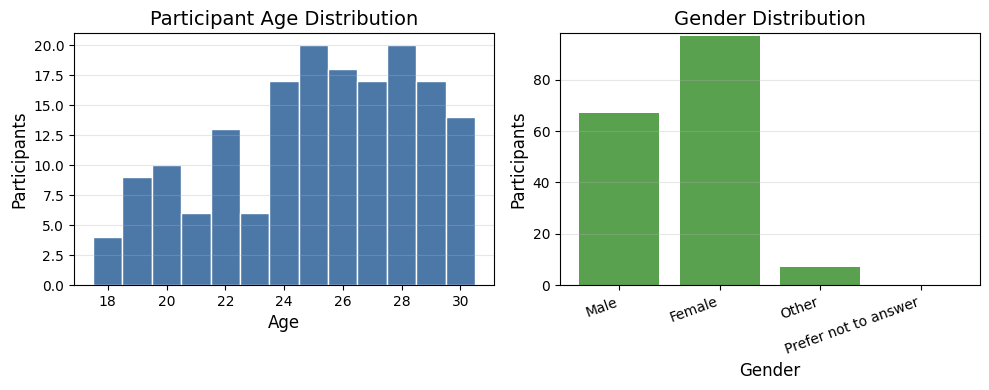

In [117]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
bins = np.arange(
    demographics_df['age'].min() - 0.5,
    demographics_df['age'].max() + 1.5,
    1,
)
ax[0].hist(demographics_df['age'].dropna(), bins=bins, color='#4c78a8', edgecolor='white')
ax[0].set_xlabel('Age', fontsize=12)
ax[0].set_ylabel('Participants', fontsize=12)
ax[0].set_title('Participant Age Distribution', fontsize=14)
ax[0].set_xticks(np.arange(demographics_df['age'].min(), demographics_df['age'].max() + 1, 2))
ax[0].grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('figures/age_histogram.png', dpi=150)

gender_counts = demographics_df['gender'].value_counts().reindex(gender_map.values(), fill_value=0)
ax[1].bar(gender_counts.index, gender_counts.values, color='#59a14f')
ax[1].set_xlabel('Gender', fontsize=12)
ax[1].set_ylabel('Participants', fontsize=12)
ax[1].set_title('Gender Distribution', fontsize=14)
ax[1].set_ylim(0, max(gender_counts.max() + 1, 1))
ax[1].grid(axis='y', alpha=0.3)
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.savefig('figures/gender_distribution.png', dpi=150)
plt.show()

## Correct Filtering (FINAL ALGO)

In [118]:
filtered_p0ids = df[df['session'] == 0]['prolific_pid'].unique()
filtered_p1ids = df[df['session'] == 1]['prolific_pid'].unique()
filtered_p2ids = df[df['session'] == 2]['prolific_pid'].unique()
filtered_participants = set(filtered_p0ids) & set(filtered_p1ids) & set(filtered_p2ids)
filtered_df = df[(df['prolific_pid'].isin(filtered_participants)) & (df['session'] >= 1)]
print(filtered_df[filtered_df['session'] == 1]['prolific_pid'].nunique())
print(filtered_df[filtered_df['session'] == 2]['prolific_pid'].nunique())
print(filtered_df[filtered_df['session'] == 3]['prolific_pid'].nunique())
print(filtered_df[filtered_df['session'] == 4]['prolific_pid'].nunique())

79
79
49
29


In [119]:
df_temp = filtered_df[['prolific_pid', 'initiation_condition', 'session']].drop_duplicates()

counts = (
    df_temp.groupby('prolific_pid')['initiation_condition']
    .unique().explode().value_counts()
)

print(counts)

initiation_condition
primacy    66
recency    58
Name: count, dtype: int64


In [25]:
primacy_df = filtered_df[filtered_df['initiation_condition'] == 'primacy']
primacy_age_df = (
    demog_raw.query("type == 'age'")[['prolific_pid', 'age']]
    .dropna()
    .drop_duplicates('prolific_pid')
)
primacy_age = primacy_df[['prolific_pid']].drop_duplicates().merge(primacy_age_df, on='prolific_pid', how='left')['age']
primacy_age.describe()

count    55.000000
mean     25.272727
std       3.319162
min      19.000000
25%      22.500000
50%      25.000000
75%      28.000000
max      30.000000
Name: age, dtype: float64

In [26]:
recency_df = filtered_df[filtered_df['initiation_condition'] == 'recency']
recency_age_df = (
    demog_raw.query("type == 'age'")[['prolific_pid', 'age']]
    .dropna()
    .drop_duplicates('prolific_pid')
)
recency_age = recency_df[['prolific_pid']].drop_duplicates().merge(recency_age_df, on='prolific_pid', how='left')['age']
recency_age.describe()

count    49.000000
mean     24.979592
std       3.375709
min      19.000000
25%      22.000000
50%      25.000000
75%      28.000000
max      30.000000
Name: age, dtype: float64

In [27]:


age_df = (
    demog_raw.query("type == 'age'")[['prolific_pid', 'age']]
    .dropna()
    .drop_duplicates('prolific_pid')
)

age_df['age'] = pd.to_numeric(age_df['age'], errors='coerce')
age_stats = age_df['age'].describe()
age_stats 

count    169.000000
mean      25.142012
std        3.367025
min       18.000000
25%       23.000000
50%       26.000000
75%       28.000000
max       30.000000
Name: age, dtype: float64

## F7(a-b). Serial Position Curve (SPC)

In [28]:
import analyses.spc as spc

In [29]:
spc_df = spc.spc_df(filtered_df)
sp_cols = [c for c in spc_df.columns if c.startswith('sp_')]
spc_df.head(5)

,prolific_pid,session,initiation_condition,sp_1,sp_2,sp_3,sp_4,sp_5,sp_6,sp_7,...,sp_11,sp_12,sp_13,sp_14,sp_15,sp_16,sp_17,sp_18,sp_19,sp_20
0,5a285307df86d80001455de5,1,recency,0.833333,0.500000,0.416667,0.750000,0.250000,0.333333,0.333333,...,0.333333,0.083333,0.000000,0.083333,0.250000,0.333333,0.166667,0.500000,0.916667,1.000000
1,5a285307df86d80001455de5,2,recency,0.916667,0.583333,0.416667,0.166667,0.083333,0.250000,0.333333,...,0.333333,0.166667,0.166667,0.250000,0.166667,0.250000,0.500000,0.666667,0.916667,1.000000
2,5a285307df86d80001455de5,3,recency,0.750000,0.916667,0.250000,0.333333,0.416667,0.333333,0.250000,...,0.333333,0.416667,0.333333,0.000000,0.083333,0.416667,0.583333,0.666667,0.916667,1.000000
3,5a285307df86d80001455de5,4,primacy,1.000000,0.750000,0.666667,0.500000,0.083333,0.500000,0.333333,...,0.166667,0.250000,0.000000,0.000000,0.083333,0.083333,0.250000,0.333333,0.750000,1.000000
4,5bf116a61e78580001dc4842,1,primacy,0.750000,0.833333,0.500000,0.333333,0.250000,0.333333,0.250000,...,0.333333,0.333333,0.333333,0.166667,0.250000,0.333333,0.416667,0.083333,0.583333,0.833333


Participants are the unit of analysis. If a participant completed more than one session in the same condition, those sessions are averaged first; condition means and 95% SE intervals are then computed across participants.

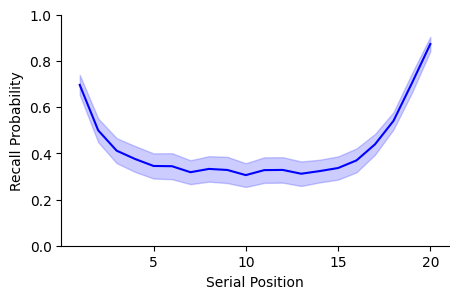

In [30]:
overall_spc = spc.spc_plot_overall(spc_df, path=f'figures/7a_spc_overall.pdf')

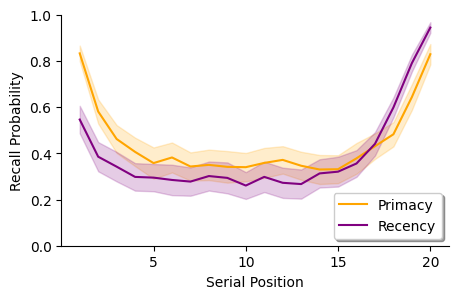

In [31]:
spc_bycond = spc.spc_plot(spc_df, path=f'figures/7b_spc_by_condition.pdf')

## F7(c): Linear Regression Gradient Trend

In [32]:
import analyses.linreg as linreg

In [33]:
linreg_df = spc_df.apply(linreg.prim_rec_lr, axis=1)
linreg_df.head(5)

,prolific_pid,session,initiation_condition,prim_slope,prim_intercept,rec_slope,rec_intercept
0,5a285307df86d80001455de5,1,recency,-0.208333,1.000000,0.250000,0.305556
1,5a285307df86d80001455de5,2,recency,-0.250000,1.138889,0.166667,0.527778
2,5a285307df86d80001455de5,3,recency,-0.250000,1.138889,0.166667,0.527778
3,5a285307df86d80001455de5,4,primacy,-0.166667,1.138889,0.333333,0.027778
4,5bf116a61e78580001dc4842,1,primacy,-0.125000,0.944444,0.375000,-0.250000


In [34]:
stat_tests.prim_rec_slopes(linreg_df)

ValueError: 5 columns passed, passed data had 7 columns

In [35]:
stat_tests.condition_contrast(linreg_df, ["prim_slope", "rec_slope"], paired=False)

,measure,test,n,t_stat,p_val,dof,p_val_fdr
0,prim_slope,welch,49,-3.726811,0.000318,101.994578,0.000955
1,rec_slope,welch,49,0.022341,0.982220,101.044694,1.000000


In [36]:
linreg_df.groupby("prolific_pid")["initiation_condition"].nunique().value_counts()

initiation_condition
2    37
1    30
Name: count, dtype: int64

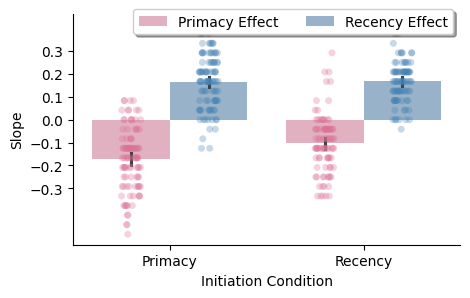

In [38]:
linreg_plot = linreg.plot_linreg(linreg_df, path=f'figures/7c_prim_rec_slopes.pdf')

## F7(d): PFR

In [39]:
import analyses.pfr as pfr

pfr_df = pfr.pfr(filtered_df)
pfr_df.head(5)

,prolific_pid,session,initiation_condition,sp_1,sp_2,sp_3,sp_4,sp_5,sp_6,sp_7,...,sp_11,sp_12,sp_13,sp_14,sp_15,sp_16,sp_17,sp_18,sp_19,sp_20
0,5a285307df86d80001455de5,1,recency,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,5a285307df86d80001455de5,2,recency,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,5a285307df86d80001455de5,3,recency,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,5a285307df86d80001455de5,4,primacy,0.916667,0.083333,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,5bf116a61e78580001dc4842,1,primacy,0.700000,0.200000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.1,0.0,0.0,0.0,0.0,0.0,0.0,0.0


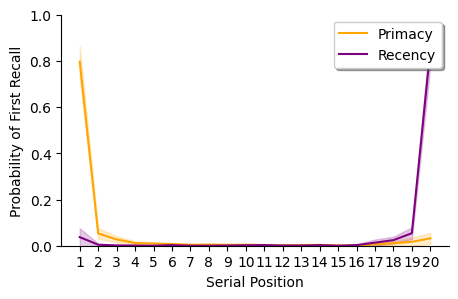

In [40]:
pfr.pfr_plot(pfr_df, path=f'figures/7d_pfr_by_condition.pdf')

In [41]:
# average sessions within participant-condition first
participant_df = (
    pfr_df
    .groupby(["prolific_pid", "initiation_condition"], as_index=False)
    [[f"sp_{i}" for i in range(1, 21)]]
    .mean()
)

# create grouped serial-position bins
participant_df["SP 1-3"] = participant_df[[f"sp_{i}" for i in range(1, 4)]].sum(axis=1)
participant_df["SP 4-17"] = participant_df[[f"sp_{i}" for i in range(4, 18)]].sum(axis=1)
participant_df["SP 18-20"] = participant_df[[f"sp_{i}" for i in range(18, 21)]].sum(axis=1)

binned_percent = (
    participant_df
    .groupby("initiation_condition")[["SP 1-3", "SP 4-17", "SP 18-20"]]
    .mean()
    .reset_index()
)

binned_percent

,initiation_condition,SP 1-3,SP 4-17,SP 18-20
0,primacy,0.877149,0.063143,0.059708
1,recency,0.042739,0.028994,0.928267


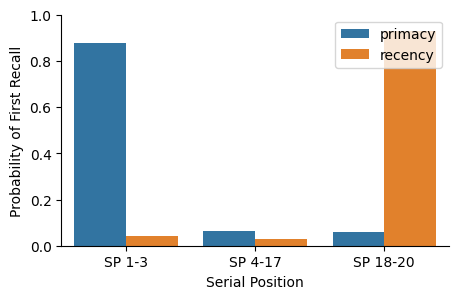

In [42]:
import seaborn as sns
import matplotlib.pyplot as plt

plot_df = binned_percent.melt(
    id_vars="initiation_condition",
    var_name="serial_position_bin",
    value_name="prob_first_recall"
)

plt.figure(figsize=(5, 3))

sns.barplot(
    data=plot_df,
    x="serial_position_bin",
    y="prob_first_recall",
    hue="initiation_condition",
)

plt.xlabel("Serial Position")
plt.ylabel("Probability of First Recall")
plt.ylim(0, 1)
plt.legend(loc='upper right')
sns.despine()
plt.show()


## F8(a-b): Mean words recalled

For each session, `mwr_sess` returns the average number of correct recalls
per list.

In [43]:
import analyses.mwr as mwr

mwr_df = mwr.mwr(filtered_df)
mwr_df.head(5)

,prolific_pid,session,initiation_condition,mwr
0,5a285307df86d80001455de5,1,recency,7.416667
1,5a285307df86d80001455de5,2,recency,7.750000
2,5a285307df86d80001455de5,3,recency,8.750000
3,5a285307df86d80001455de5,4,primacy,7.166667
4,5bf116a61e78580001dc4842,1,primacy,7.583333


In [44]:
stat_tests.condition_contrast(mwr_df, ["mwr"], paired=False)

,measure,test,n,t_stat,p_val,dof,p_val_fdr
0,mwr,welch,49,1.503169,0.135887,101.946802,0.135887


In [45]:
mwr2_df = mwr_df[mwr_df['session']==2]
stat_tests.condition_contrast(mwr2_df, ["mwr"], paired=False)

,measure,test,n,t_stat,p_val,dof,p_val_fdr
0,mwr,welch,28,1.898017,0.062289,62.841633,0.062289


In [46]:
import importlib
import analyses.mwr as mwr 
importlib.reload(mwr)

<module 'analyses.mwr' from 'c:\\Users\\andre\\RecallInitiation2026\\analyses\\mwr.py'>

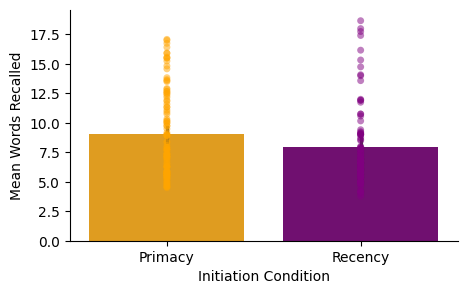

In [47]:
mwr.mwr_plot(mwr_df, path=f'figures/8a_mwr_by_condition.pdf')

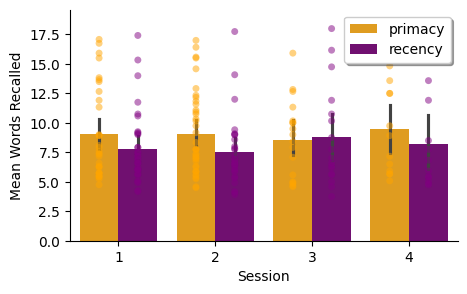

In [48]:
mwr.mwr_plot_by_session(mwr_df, path=f'figures/8b_mwr_by_condition_by_session.pdf')

## F9(a-b) R1 Intrusion Probability

In [49]:
import analyses.r1_intrusion as r1_intrusion

r1_intrusion_data = r1_intrusion.r1_intrusion_df(filtered_df)
r1_intrusion_data.head(5)

,prolific_pid,session,initiation_condition,prop_wrong
0,5a285307df86d80001455de5,1,recency,0.000000
1,5a285307df86d80001455de5,2,recency,0.000000
2,5a285307df86d80001455de5,3,recency,0.000000
3,5a285307df86d80001455de5,4,primacy,0.000000
4,5bf116a61e78580001dc4842,1,primacy,0.166667


In [50]:
summary = (
    r1_intrusion_data
    .groupby("initiation_condition")["prop_wrong"]
    .agg(mean="mean", sd="std")
)

print(summary)

                          mean        sd
initiation_condition                    
primacy               0.069444  0.098170
recency               0.028986  0.053043


In [51]:
stat_tests.condition_contrast(r1_intrusion_data[r1_intrusion_data["session"]==1], ["prop_wrong"], paired=False)

,measure,test,n,t_stat,p_val,dof,p_val_fdr
0,prop_wrong,welch,32,3.20491,0.002745,37.811168,0.002745


In [52]:
for sess in range(1,5):
    r1_intrusion_prim = r1_intrusion_data[(r1_intrusion_data['session'] == sess) & (r1_intrusion_data['initiation_condition'] == 'primacy')]['prop_wrong'].mean()
    print(f'Session {sess} - Primacy: = {r1_intrusion_prim:.3f}')
    r1_intrusion_rec = r1_intrusion_data[(r1_intrusion_data['session'] == sess) & (r1_intrusion_data['initiation_condition'] == 'recency')]['prop_wrong'].mean()
    print(f'Session {sess} - Recency: = {r1_intrusion_rec:.3f}')

Session 1 - Primacy: = 0.094
Session 1 - Recency: = 0.021
Session 2 - Primacy: = 0.058
Session 2 - Recency: = 0.039
Session 3 - Primacy: = 0.074
Session 3 - Recency: = 0.049
Session 4 - Primacy: = 0.038
Session 4 - Recency: = 0.000


In [53]:
import importlib
import analyses.r1_intrusion as r1_intrusion 
importlib.reload(r1_intrusion)

<module 'analyses.r1_intrusion' from 'c:\\Users\\andre\\RecallInitiation2026\\analyses\\r1_intrusion.py'>

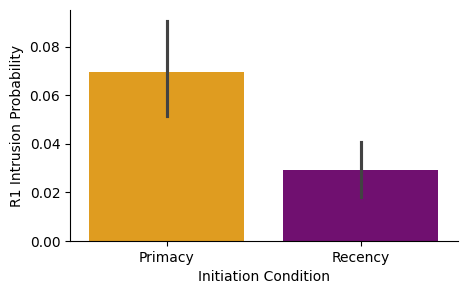

In [54]:
r1_intrusion.r1_intrusion_overall(r1_intrusion_data, path=f'figures/9a_r1_intrusion_overall.pdf')

## F9(c) R1 Response Time

In [197]:
import analyses.rt_init as rt_init

rt_init_df = rt_init.rt_init_df(filtered_df)
rt_init_trial_df = rt_init.rt_init_trial_df(filtered_df)
rt_init_df.head(5)

,prolific_pid,session,initiation_condition,rt_initial
0,5a285307df86d80001455de5,1,recency,820.533333
1,5a285307df86d80001455de5,2,recency,1493.491667
2,5a285307df86d80001455de5,3,recency,892.050000
3,5a285307df86d80001455de5,4,primacy,2623.766667
4,5bf116a61e78580001dc4842,1,primacy,2840.130000


In [198]:
rt_init_df.groupby("initiation_condition")["rt_initial"].agg(mean="mean", sd="std")

,mean,sd
initiation_condition,,
primacy,2188.689456,1580.843472
recency,1452.040896,923.244830


In [199]:
stat_tests.condition_contrast(rt_init_df, ["rt_initial"], paired=False)

,measure,test,n,t_stat,p_val,dof,p_val_fdr
0,rt_initial,welch,58,2.919651,0.004216,115.141477,0.004216


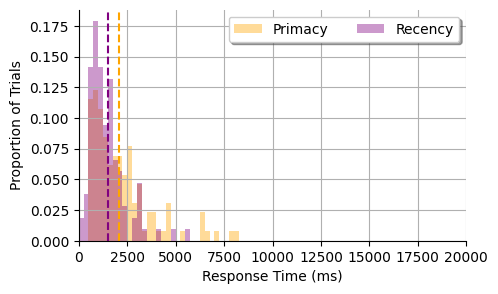

In [200]:
rt_init_plot = rt_init.rt_init_plot(rt_init_trial_df, rt_init_data=rt_init_df, path=f'figures/9c_rt_init_by_condition.pdf')

## F10(A-B) PLIs and ELIs

In [59]:
import analyses.pli_eli as pli_eli

plieli_df = pli_eli.intrusion_rates(filtered_df)
plieli_df.head(10)

,prolific_pid,session,initiation_condition,eli,pli
0,5a285307df86d80001455de5,1,recency,0.666667,0.250
1,5a285307df86d80001455de5,2,recency,0.250000,0.125
2,5a285307df86d80001455de5,3,recency,0.666667,0.125
3,5a285307df86d80001455de5,4,primacy,0.500000,0.000
4,5bf116a61e78580001dc4842,1,primacy,0.666667,0.250
5,5bf116a61e78580001dc4842,2,primacy,0.583333,0.125
6,5bf116a61e78580001dc4842,3,primacy,0.333333,0.125
7,608832bd3e28d0394114ffa4,1,primacy,0.833333,0.875
8,608832bd3e28d0394114ffa4,2,recency,0.166667,0.500
9,6109f02b5f6b3477fa8ddd8a,1,recency,0.500000,0.250


In [60]:
plieli_recency = plieli_df[plieli_df['initiation_condition']=='recency']
plieli_recency_eli = plieli_recency['eli'].tolist()
print(f"Recency ELI: {np.mean(plieli_recency_eli)}")
plieli_recency_pli = plieli_recency['pli'].tolist()
print(f"Recency PLI: {np.mean(plieli_recency_pli)}")

plieli_primacy = plieli_df[plieli_df['initiation_condition']=='primacy']
plieli_primacy_eli = plieli_primacy['eli'].tolist()
print(f"Primacy ELI: {np.mean(plieli_primacy_eli)}")
plieli_primacy_pli = plieli_primacy['pli'].tolist()
print(f"Primacy PLI: {np.mean(plieli_primacy_pli)}")


Recency ELI: 0.8070652173913043
Recency PLI: 0.3546195652173913
Primacy ELI: 0.7165032679738562
Primacy PLI: 0.20588235294117646


In [61]:
stat_tests.condition_contrast(plieli_df, ['eli'], paired=False)

,measure,test,n,t_stat,p_val,dof,p_val_fdr
0,eli,welch,49,-0.550542,0.583384,85.423132,0.583384


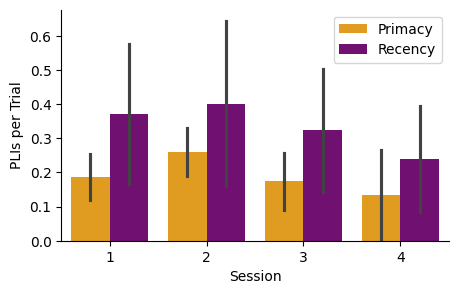

In [62]:
pli_eli.pli_plot_by_session(plieli_df, path=f'figures/10a_pli.pdf')

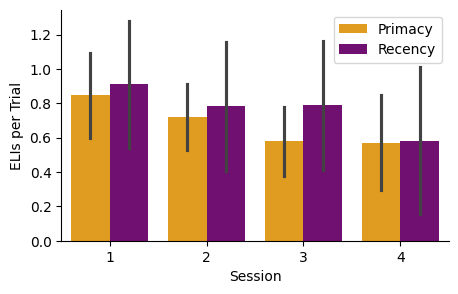

In [63]:
pli_eli.eli_plot_by_session(plieli_df, path=f'figures/10b_eli.pdf')

## F10(C): Final IRTs

In [64]:
import importlib 
import analyses.irt as irt 
importlib.reload(irt)

<module 'analyses.irt' from 'c:\\Users\\andre\\RecallInitiation2026\\analyses\\irt.py'>

In [65]:
import analyses.irt as irt 

irt_final_df = irt.irt_final_df(filtered_df, n_final=4)
irt_final_df.head(5)

,prolific_pid,session,initiation_condition,relative_output_position,irt
0,5a285307df86d80001455de5,1,recency,-4.0,1745.900000
1,5a285307df86d80001455de5,1,recency,-3.0,1840.380000
2,5a285307df86d80001455de5,1,recency,-2.0,1908.854545
3,5a285307df86d80001455de5,1,recency,-1.0,3500.583333
4,5a285307df86d80001455de5,1,recency,0.0,5408.950000


In [66]:
stat_tests.condition_contrast(irt_final_df[irt_final_df['relative_output_position']==-4.0], ['irt'], paired=False)

,measure,test,n,t_stat,p_val,dof,p_val_fdr
0,irt,welch,48,0.374103,0.709164,94.761858,0.709164


In [67]:
summary = (
    irt_final_df
    .groupby(["initiation_condition", "relative_output_position"])["irt"]
    .agg(mean="mean", sd="std")
    .reset_index()
)

print(summary)

  initiation_condition  relative_output_position         mean           sd
0              primacy                      -4.0  2928.893726  1278.553884
1              primacy                      -3.0  3145.525092  1315.930859
2              primacy                      -2.0  3603.976653  1367.760467
3              primacy                      -1.0  4311.938576  1999.366709
4              primacy                       0.0  6650.315144  3534.237688
5              recency                      -4.0  2803.954659  1472.463106
6              recency                      -3.0  3169.067236  1580.864834
7              recency                      -2.0  3472.430572  1712.258241
8              recency                      -1.0  4615.477148  2392.209233
9              recency                       0.0  6970.777407  3534.119722


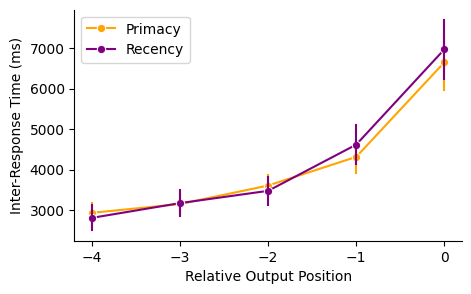

In [68]:
irt.irt_final_plot(irt_final_df, 5, path=f'figures/10c_irt_final.pdf')

In [69]:
irt_tot_df = irt.irt_tot_df(filtered_df)
irt_tot_df.head(5)

,prolific_pid,session,initiation_condition,ncr,ncr_bin,total_irt,irt_h1,irt_h2,irt_delta
0,5a285307df86d80001455de5,1,recency,5,2,20148.900000,1217.80,17296.900000,16079.100000
1,5a285307df86d80001455de5,1,recency,6,3,37961.050000,7490.00,30471.050000,22981.050000
2,5a285307df86d80001455de5,1,recency,7,3,8773.400000,2680.35,4252.500000,1572.150000
3,5a285307df86d80001455de5,1,recency,8,4,31741.566667,9052.40,22689.166667,13636.766667
4,5a285307df86d80001455de5,1,recency,9,4,22961.400000,4770.05,16986.150000,12216.100000


In [70]:
stat_tests.condition_contrast(irt_tot_df[irt_tot_df['ncr_bin']==1], ['irt_delta'], paired=False)

,measure,test,n,t_stat,p_val,dof,p_val_fdr
0,irt_delta,welch,15,-1.962073,0.058395,32.386759,0.058395


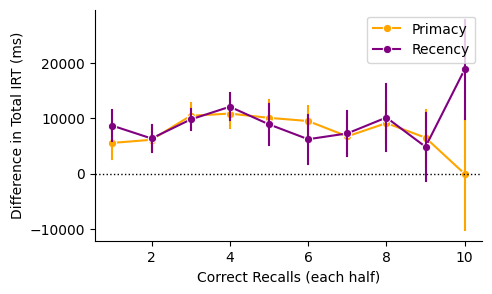

In [71]:
irt.irt_tot_plot(irt_tot_df, path=f'figures/10e_irt_total.pdf')

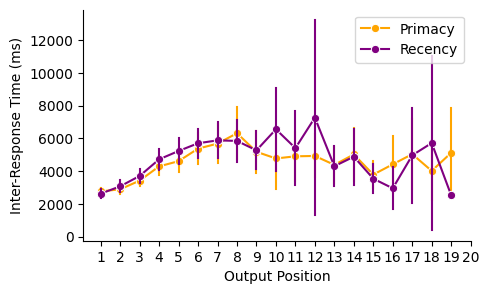

In [73]:
irt_first_df = irt.irt_first_df(filtered_df, n_first=20)
irt.irt_first_plot(irt_first_df, n_first=20, path=f'figures/10d_irt_first.pdf')

In [74]:
stat_tests.condition_contrast(irt_first_df[irt_first_df['output_position']==16], ['irt'], paired=False)

,measure,test,n,t_stat,p_val,dof,p_val_fdr
0,irt,welch,6,1.394734,0.188377,11.999997,0.188377


## F11(A-B). Temporal clustering score

In [75]:
import importlib 
import analyses.tcl as tcl
importlib.reload(tcl)

<module 'analyses.tcl' from 'c:\\Users\\andre\\RecallInitiation2026\\analyses\\tcl.py'>

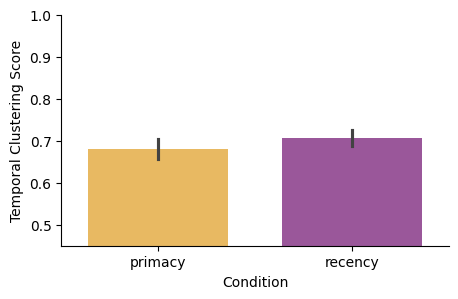

In [76]:
tcl_df = tcl.tcl(filtered_df)
tcl.plot_tcl(tcl_df, path="figures/11a_tcl_overall.pdf")

In [77]:
stat_tests.condition_contrast(tcl_df, ['tcl'], paired=False)

,measure,test,n,t_stat,p_val,dof,p_val_fdr
0,tcl,welch,49,-1.793694,0.075905,99.330853,0.075905


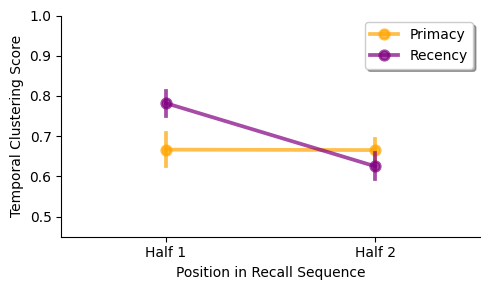

In [78]:
tcl_h_df = tcl.tcl_h(filtered_df)
tcl.plot_tcl_h(tcl_h_df, path="figures/11b_tcl_half.pdf")

In [79]:
stat_tests.condition_contrast(tcl_h_df, ['tcl_h1', 'tcl_h2', 'tcl_delta'], paired=False)

,measure,test,n,t_stat,p_val,dof,p_val_fdr
0,tcl_h1,welch,49,-4.409606,2.673138e-05,97.273468,7.351130e-05
1,tcl_h2,welch,49,1.845455,6.795426e-02,99.194235,1.245828e-01
2,tcl_delta,welch,49,6.167324,1.720977e-08,94.221657,9.465375e-08


## F11(C) Lag-CRP

Lag-CRP is computed per session, then averaged within participant-condition
before plotting condition curves.


In [80]:
import importlib
import analyses.lcrp as lcrp
importlib.reload(lcrp)

<module 'analyses.lcrp' from 'c:\\Users\\andre\\RecallInitiation2026\\analyses\\lcrp.py'>

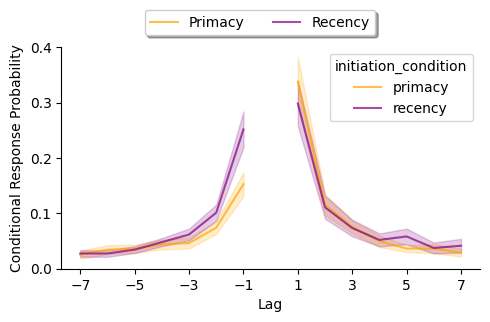

In [81]:
import analyses.lcrp as lcrp

lcrp_df = lcrp.lag_crp(filtered_df)
lcrp.plot_lcrp(lcrp_df, max_lag = 7, path='figures/11c_lcrp.pdf')

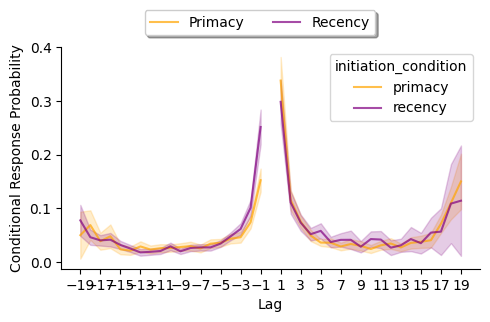

In [82]:
lcrp.plot_lcrp(lcrp_df, max_lag = 19, path='figures/11e_lcrp_full.pdf')

In [86]:
fwd_asym_df = lcrp_df.apply(lambda row: lcrp.forward_asymmetry(row, n=1), axis=1)

stat_tests.condition_contrast(fwd_asym_df, ["asym"], paired=False)

,measure,test,n,t_stat,p_val,dof,p_val_fdr
0,asym,welch,49,3.678874,0.000378,101.12317,0.000378


In [87]:
stat_tests.condition_contrast(lcrp_df, ["lp_1", "ln_1"], paired=False)


,measure,test,n,t_stat,p_val,dof,p_val_fdr
0,lp_1,welch,49,1.292769,0.199012,101.985053,0.298518
1,ln_1,welch,49,-4.985003,0.000003,85.177789,0.000010


In [88]:
tmp = stat_tests.participant_condition_mean(lcrp_df, ["lp_1", "ln_1"])

tmp.groupby("initiation_condition")[["lp_1", "ln_1"]].agg(["mean", "sem", "count"])

stat_tests.condition_contrast(fwd_asym_df, ["asym"], paired=False)


,measure,test,n,t_stat,p_val,dof,p_val_fdr
0,asym,welch,49,3.678874,0.000378,101.12317,0.000378


## F11(d) Semantic Clustering

In [90]:
wordpool = list(np.loadtxt('data/wordpool/wordpool_ltpFR3.txt', dtype=str))
w2v_scores = np.loadtxt('data/wordpool/w2v_scores_ltpFR3.txt')

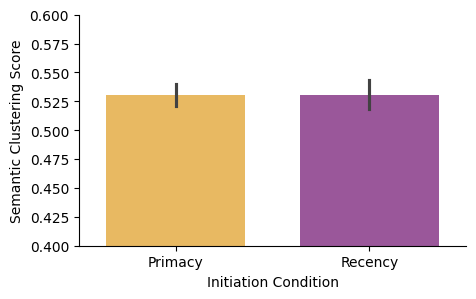

In [91]:
scl_df = analyses.scl(filtered_df, wordpool, w2v_scores)
analyses.plot_scl(scl_df, path="figures/11d_scl_by_condition.pdf")

In [94]:
stat_tests.one_sample(scl_df, ["scl"], popmean=0.5)

,initiation_condition,measure,test,n,t_stat,p_val,dof,p_val_fdr
0,primacy,scl,one_sample,55,6.833407,7.680773e-09,54,2.304232e-08
1,recency,scl,one_sample,49,4.129764,1.442256e-04,48,2.163384e-04


In [95]:
# 3) stats
stat_tests.condition_contrast(scl_df, ["scl"], paired=False)

,measure,test,n,t_stat,p_val,dof,p_val_fdr
0,scl,welch,49,0.237843,0.812586,83.478169,0.812586
